In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
titanic=sns.load_dataset("titanic")

In [4]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [16]:
features=["pclass","sex","fare","embarked", "age"]
target=["survived"]

In [17]:
#Filling the missing values with the help of imputer
from sklearn.impute import SimpleImputer

imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [18]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [19]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [20]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [21]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [22]:
X=titanic[features]
y=titanic[target]

In [23]:
X.head()


,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [24]:
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [25]:
X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [26]:
X_test.head()

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


In [28]:
X_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [31]:
#Decision Tree Model-no pruning
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test)

print("accuracy:", accuracy_score(y_test, y_pred))

accuracy: 0.7653631284916201


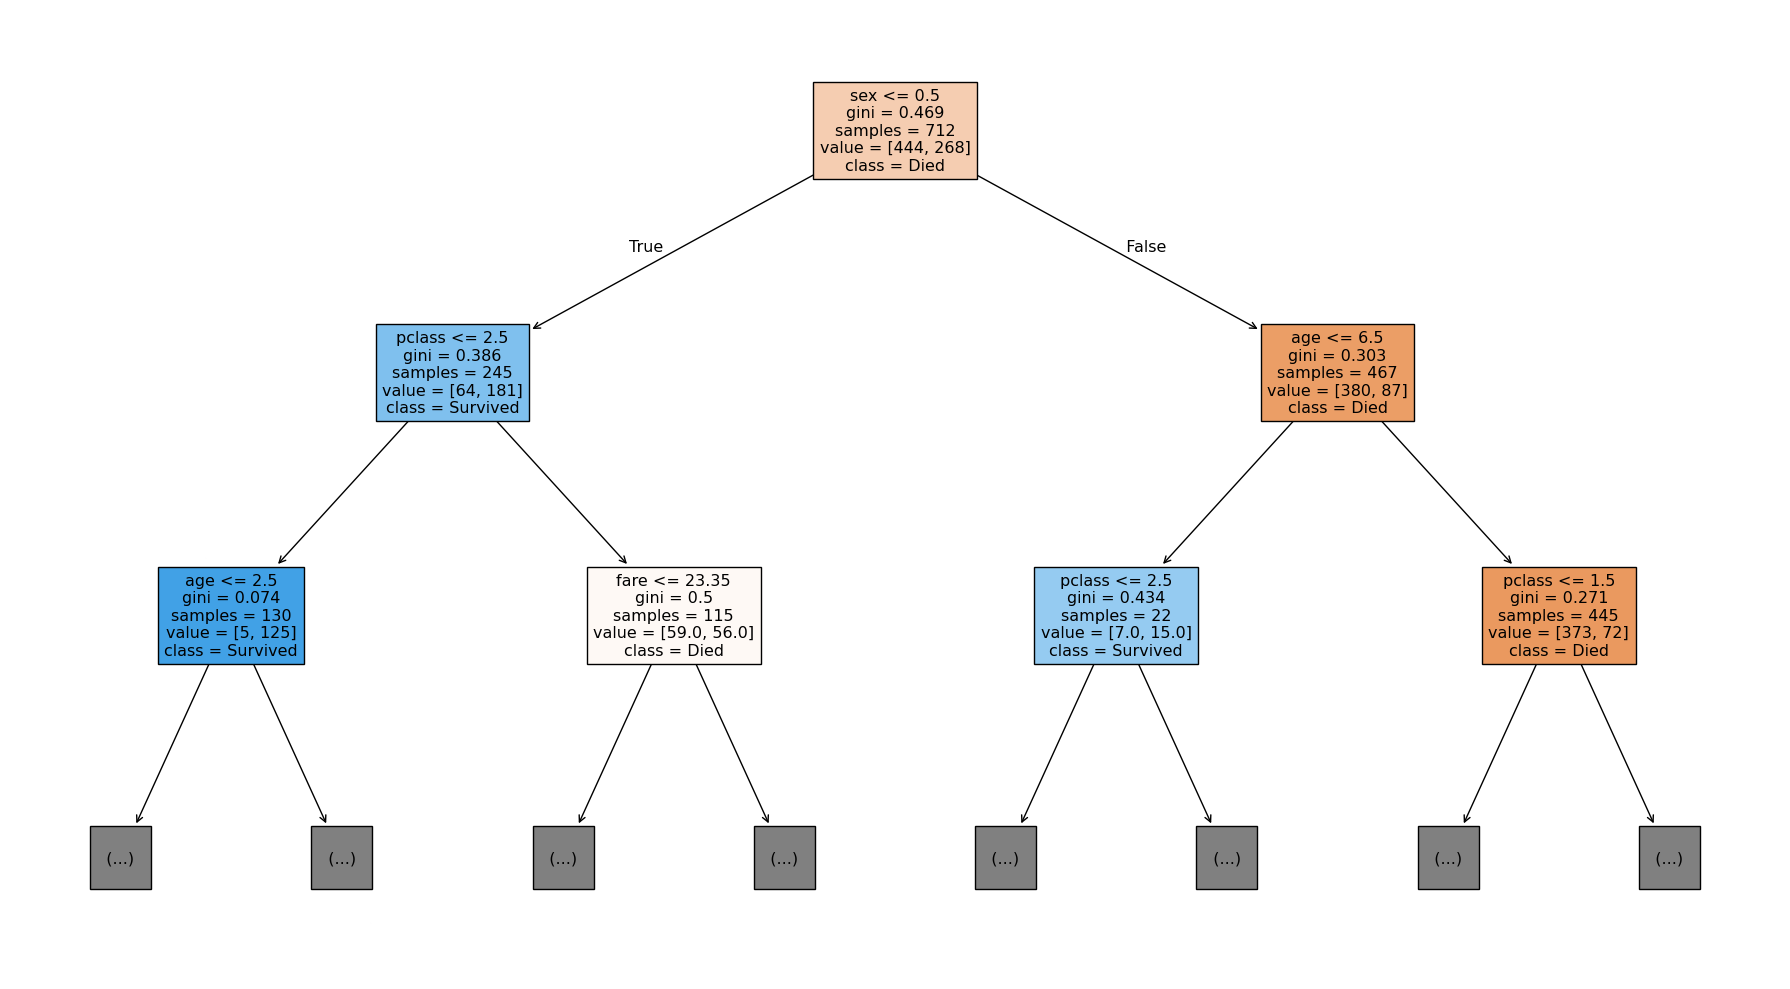

In [38]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()
plt.show()

for depth=1, accuracy=0.7821229050279329
for depth=2, accuracy=0.7653631284916201
for depth=3, accuracy=0.7988826815642458
for depth=4, accuracy=0.7988826815642458


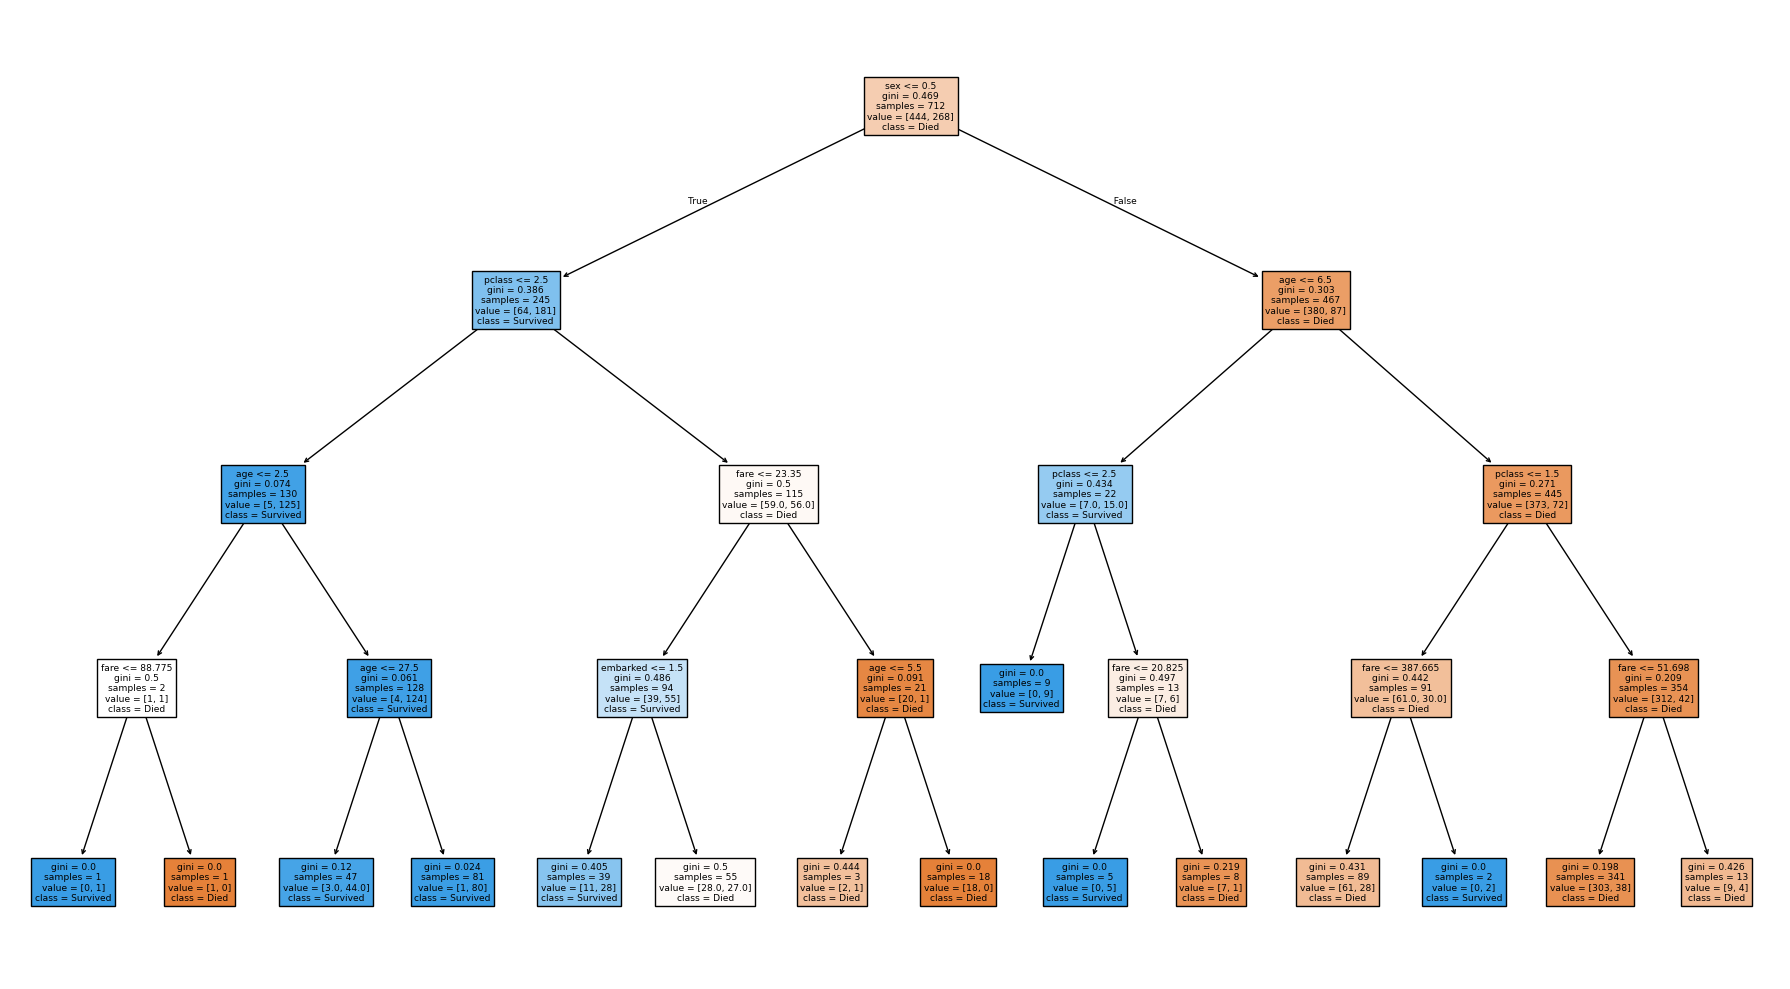

for depth=5, accuracy=0.7988826815642458
for depth=6, accuracy=0.8044692737430168
for depth=8, accuracy=0.7932960893854749
for depth=9, accuracy=0.7877094972067039
for depth=10, accuracy=0.7932960893854749


In [50]:
#Decision tree with pre pruning
max_depth=[1,2,3,4,5,6,8,9,10]

for depth in max_depth:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    acc=model.score(X_test, y_test)
    print(f"for depth={depth}, accuracy={acc}")

    if depth==4:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True,
        
        )
        
        plt.tight_layout()
        plt.show()



for sample split=5, accuracy=0.7988826815642458
for sample split=10, accuracy=0.7988826815642458


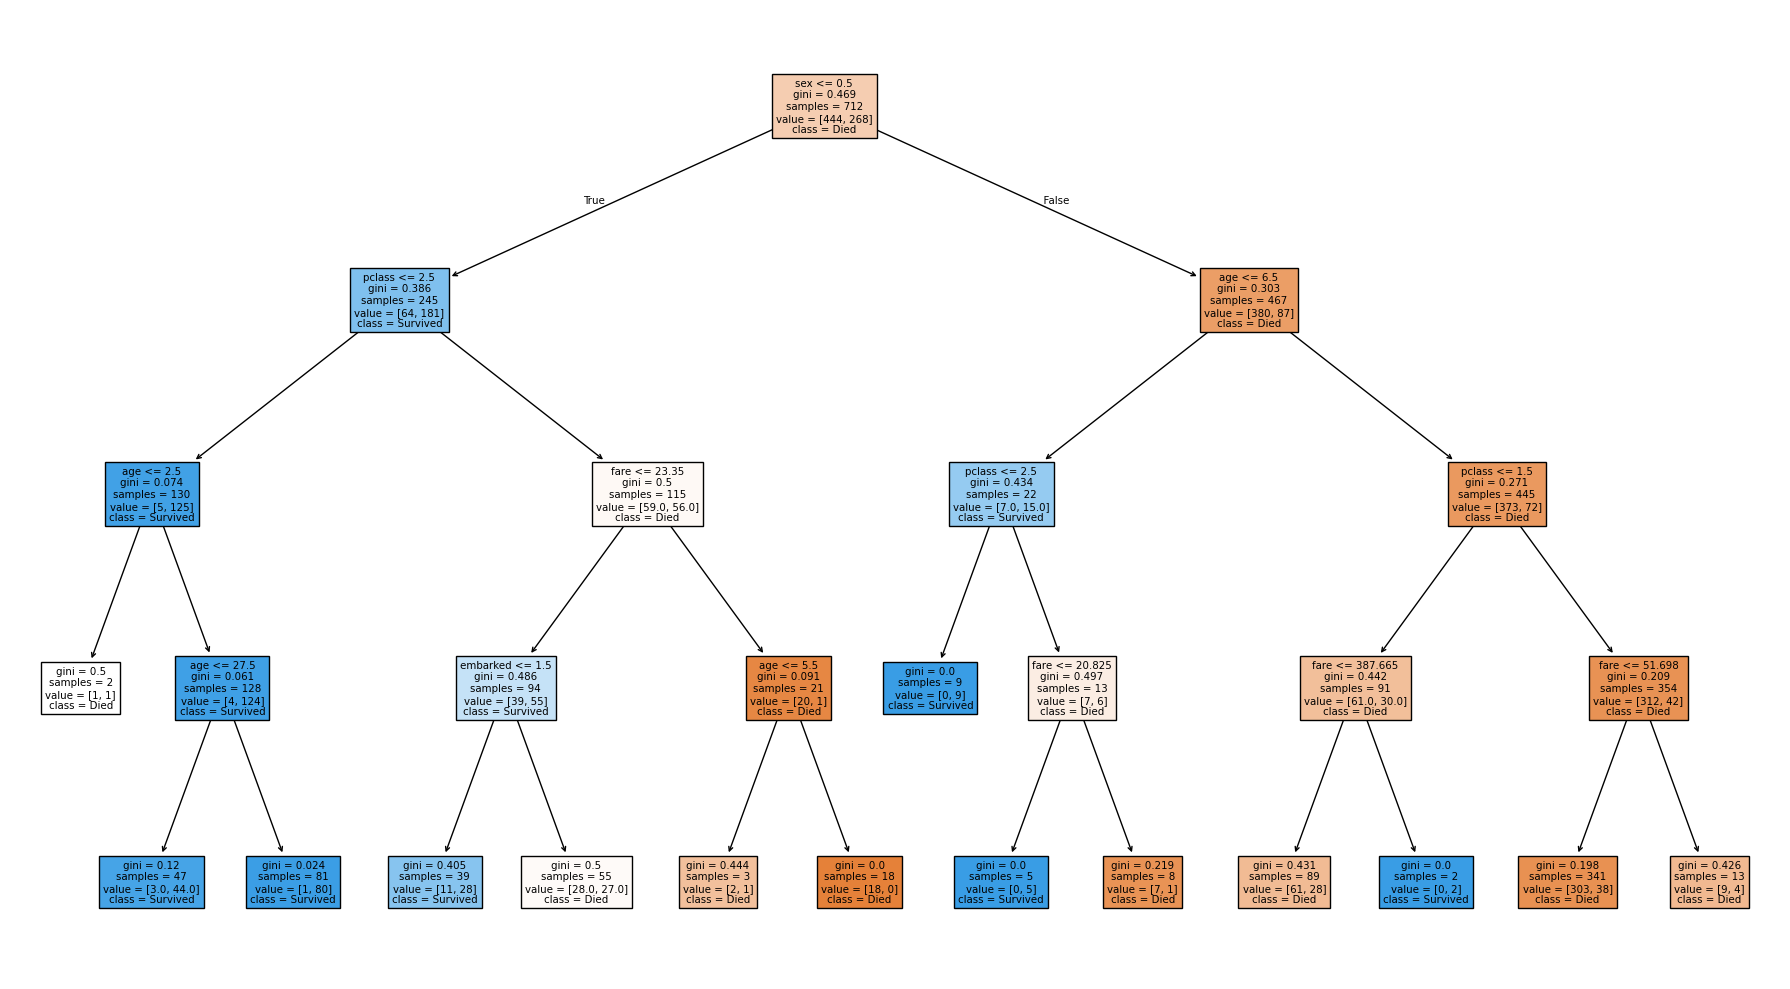

for sample split=15, accuracy=0.7988826815642458
for sample split=20, accuracy=0.7988826815642458
for sample split=25, accuracy=0.7932960893854749
for sample split=20, accuracy=0.7988826815642458


In [51]:
min_samples_splits=[5,10,15,20,25,20]

for split in min_samples_splits:
    model=DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc=model.score(X_test, y_test)
    print(f"for sample split={split}, accuracy={acc}")

    if split==10:
        plt.figure(figsize=(18,10))
        plot_tree(
            model,feature_names=X.columns,
            class_names=["Died", "Survived"],
            filled=True,
        
        )
        
        plt.tight_layout()
        plt.show()


In [54]:
#Post Pruning

full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
path=full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas=path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [60]:
#Train our model for all alphas
trees=[]
for alphas in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42, ccp_alpha=alphas)
    model.fit(X_train, y_train)
    model.score(X_test, y_test)

    trees.append((model, alphas))

In [61]:
best_acc=0
best_alpha=0

for model, alpha in trees:
    curr_acc=model.score(X_test, y_test)
    if curr_acc>best_acc:
        best_acc=curr_acc
        best_alpha=alpha

In [62]:
best_alpha

np.float64(0.0015407231242023183)

In [63]:
best_acc

0.8379888268156425

In [68]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


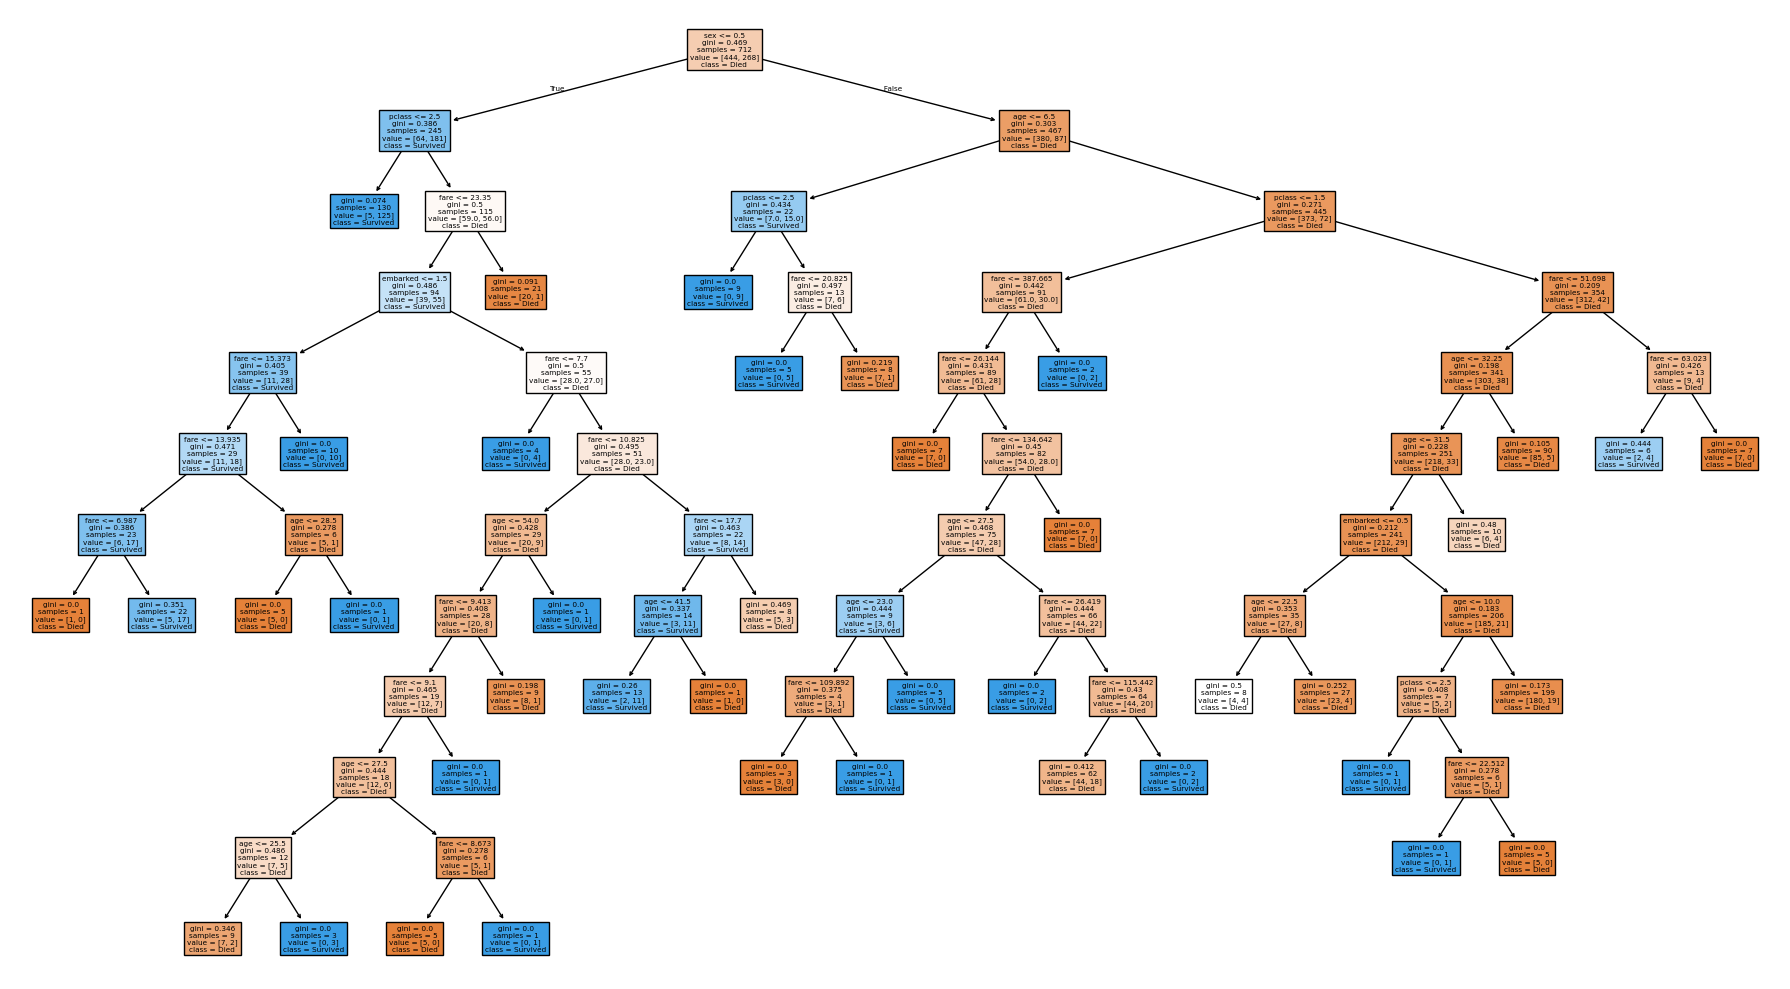

In [69]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
        
)
        
plt.tight_layout()
plt.show()